# Часть 1: K-Means
## Кластеризация исполнителей по жанрам

В этом задании вы попробуете кластеризовать исполнителей по жанрам на основе данных о прослушивании.

В матрице sample_matrix по строкам стоят пользователи, а по столбцам - исполнители.

Для каждой пары (пользователь,исполнитель) в таблице стоит число - доля (процент) прослушивания этого исполнителя выбранным пользователем.

## Импорт библиотек, загрузка данных

In [92]:
import pandas as pd
import numpy as np

In [93]:
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')

In [94]:
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Задание

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [95]:
ratings = ratings.T
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [96]:
ratings = ratings.drop('user', axis=0)
ratings.head(5)

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Вопрос для Quiz

Сколько строк осталось в матрице ratings?

Заполните пропуски нулями.

In [97]:
ratings.shape

(1000, 5000)

Нормализуйте данные при помощи `normalize`.

In [98]:
from sklearn.preprocessing import normalize

ratings.fillna(0, inplace=True)
ratings_norm = pd.DataFrame(normalize(ratings), index=ratings.index, columns=ratings.columns)
ratings_norm.head(5)

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице (сделайте fit, а затем вычислите кластеры при помощи predict).

In [99]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(ratings_norm)
pred = kmeans.predict(ratings_norm)

Выведите на экран центры кластеров (центроиды)

In [100]:
# ваш код здесь

centroids = kmeans.cluster_centers_
centroids

array([[ 1.67830066e-03,  1.51788304e-18,  1.21266299e-04, ...,
        -2.38524478e-18,  0.00000000e+00, -1.08420217e-18],
       [ 1.88589225e-03,  1.06654937e-04,  8.09463797e-04, ...,
         2.68938484e-03,  0.00000000e+00,  1.19757379e-03],
       [ 3.55821439e-04,  1.44240237e-04,  1.73721732e-03, ...,
         1.59066890e-04,  5.16646974e-03,  4.29001462e-04],
       [-3.68628739e-18,  1.60551391e-03,  1.92730597e-03, ...,
         8.36063816e-03,  0.00000000e+00, -1.08420217e-18],
       [ 2.14071913e-03,  1.93800900e-03,  1.67549440e-03, ...,
         3.78204679e-04,  1.58093924e-03,  3.39174746e-03]])

Для каждого кластера найдем топ-10 исполнителей, наиболее близких к центроидам соотвествующего кластера.

Схожесть исполнителей будем считать по косинусной мере (spatial.distance.cosine).

## Quiz

Вычислите расстояние между "the beatles" и "coldplay". Ответ округлите до сотых.


In [101]:
from scipy import spatial

beatles = ratings_norm.loc['the beatles']
coldplay = ratings_norm.loc['coldplay']
dist = spatial.distance.cosine(beatles, coldplay)
round(dist, 2)

np.float64(0.9)

Ниже для вашего удобства написана функция, принимающая на вход:
* np.array points - все точки кластера
* pt - центроид кластера
* K = 10 - число
Функция возвращает K индексов объектов (строк в массиве points), ближайших к центроиду.

In [102]:
def pClosest(points, pt, K=10):
    ind = [i[0] for i in sorted(enumerate(points), key=lambda x: spatial.distance.cosine(x[1], pt))]

    return ind[:K]

Примените функцию pClosest (или придумайте свой подход) и выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду.

In [103]:
X = ratings_norm
X['cluster'] = pred
X.head(5)

,0,1,2,3,4,5,6,7,8,9,...,4991,4992,4993,4994,4995,4996,4997,4998,4999,cluster
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000,3
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000,4
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622,1
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,4


In [104]:
clusters = [group for group in X.groupby('cluster')]
for i in range(len(clusters)):
    cluster_data = clusters[i][1].drop(columns=['cluster'])
    closest_pos = pClosest(np.array(cluster_data), centroids[i])
    print(cluster_data.iloc[closest_pos].index)

Index(['nas', 'jay-z', 'kanye west', 'lupe the gorilla',
       'a tribe called quest', 'the roots featuring d'angelo', 'gangstarr',
       'little brother', 'lil' wayne', 'murs and 9th wonder'],
      dtype='object')
Index(['fall out boy', 'the all-americian rejects', 'paramore',
       'kelly clarkson', 'john mayer', 'the fray', 'maroon5',
       'dashboard confesssional', 'somethings corporate', 'coldplay'],
      dtype='object')
Index(['brand new', 'blink-182', 'alkaline trio', 'against me!', 'underoath',
       'descendents', 'new found glory', 'less than jake', 'thrice',
       'chiodos'],
      dtype='object')
Index(['the beatles', 'the rolling stones', 'dylan. bob', 'who',
       'led zeppelin.', 'miles davis.', 'simon and garfunkel', 'young, neil',
       'pink fluid', 'velvet underground'],
      dtype='object')
Index(['radiohead', 'the arcade fire', 'the shins', 'sufjan stevens',
       'belle and sebastian', 'broken social scene', 'the pixies',
       'animal collective', '

## Quiz

Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

# Часть 2: сравнение алгоритмов кластеризации

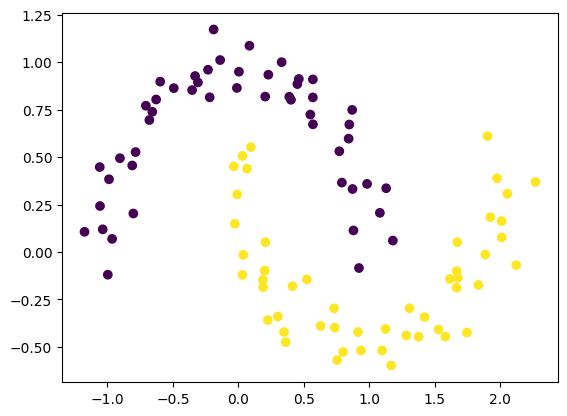

In [105]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons

data = make_moons(n_samples=100, noise=0.1, random_state=42)

X = data[0]
y = data[1]

plt.scatter(X[:,0], X[:,1], c=y)

Далее вы попробуете разные кластеризации для поиска кластеров. Также замеряйте время работы каждого метода.

Попробуйте найти кластеры при помощи KMeans

In [112]:
%time
another_kmeans = KMeans(n_clusters=2, random_state=42)
another_kmeans.fit(X)
pred = another_kmeans.predict(X)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.53 µs


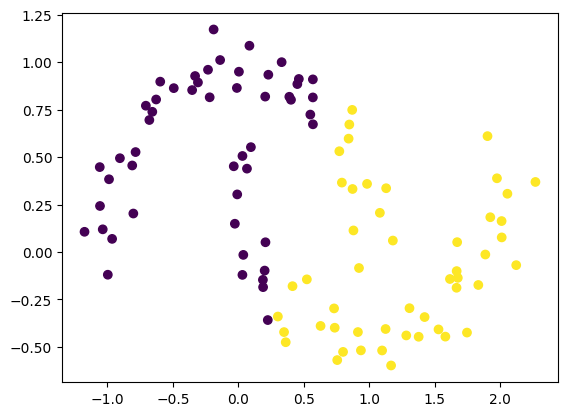

In [113]:
plt.scatter(X[:,0], X[:,1], c=pred)

## Quiz

Подберите $\varepsilon$ и min_samples в DBSCAN, чтобы наилучшим образом найти кластеры.
Ищите гиперпараметры из диапазонов:
* eps in [0.05, 0.1, 0.2, 0.28, 0.3, 0.32]
* min_samples in [4, 5, 6, 7]

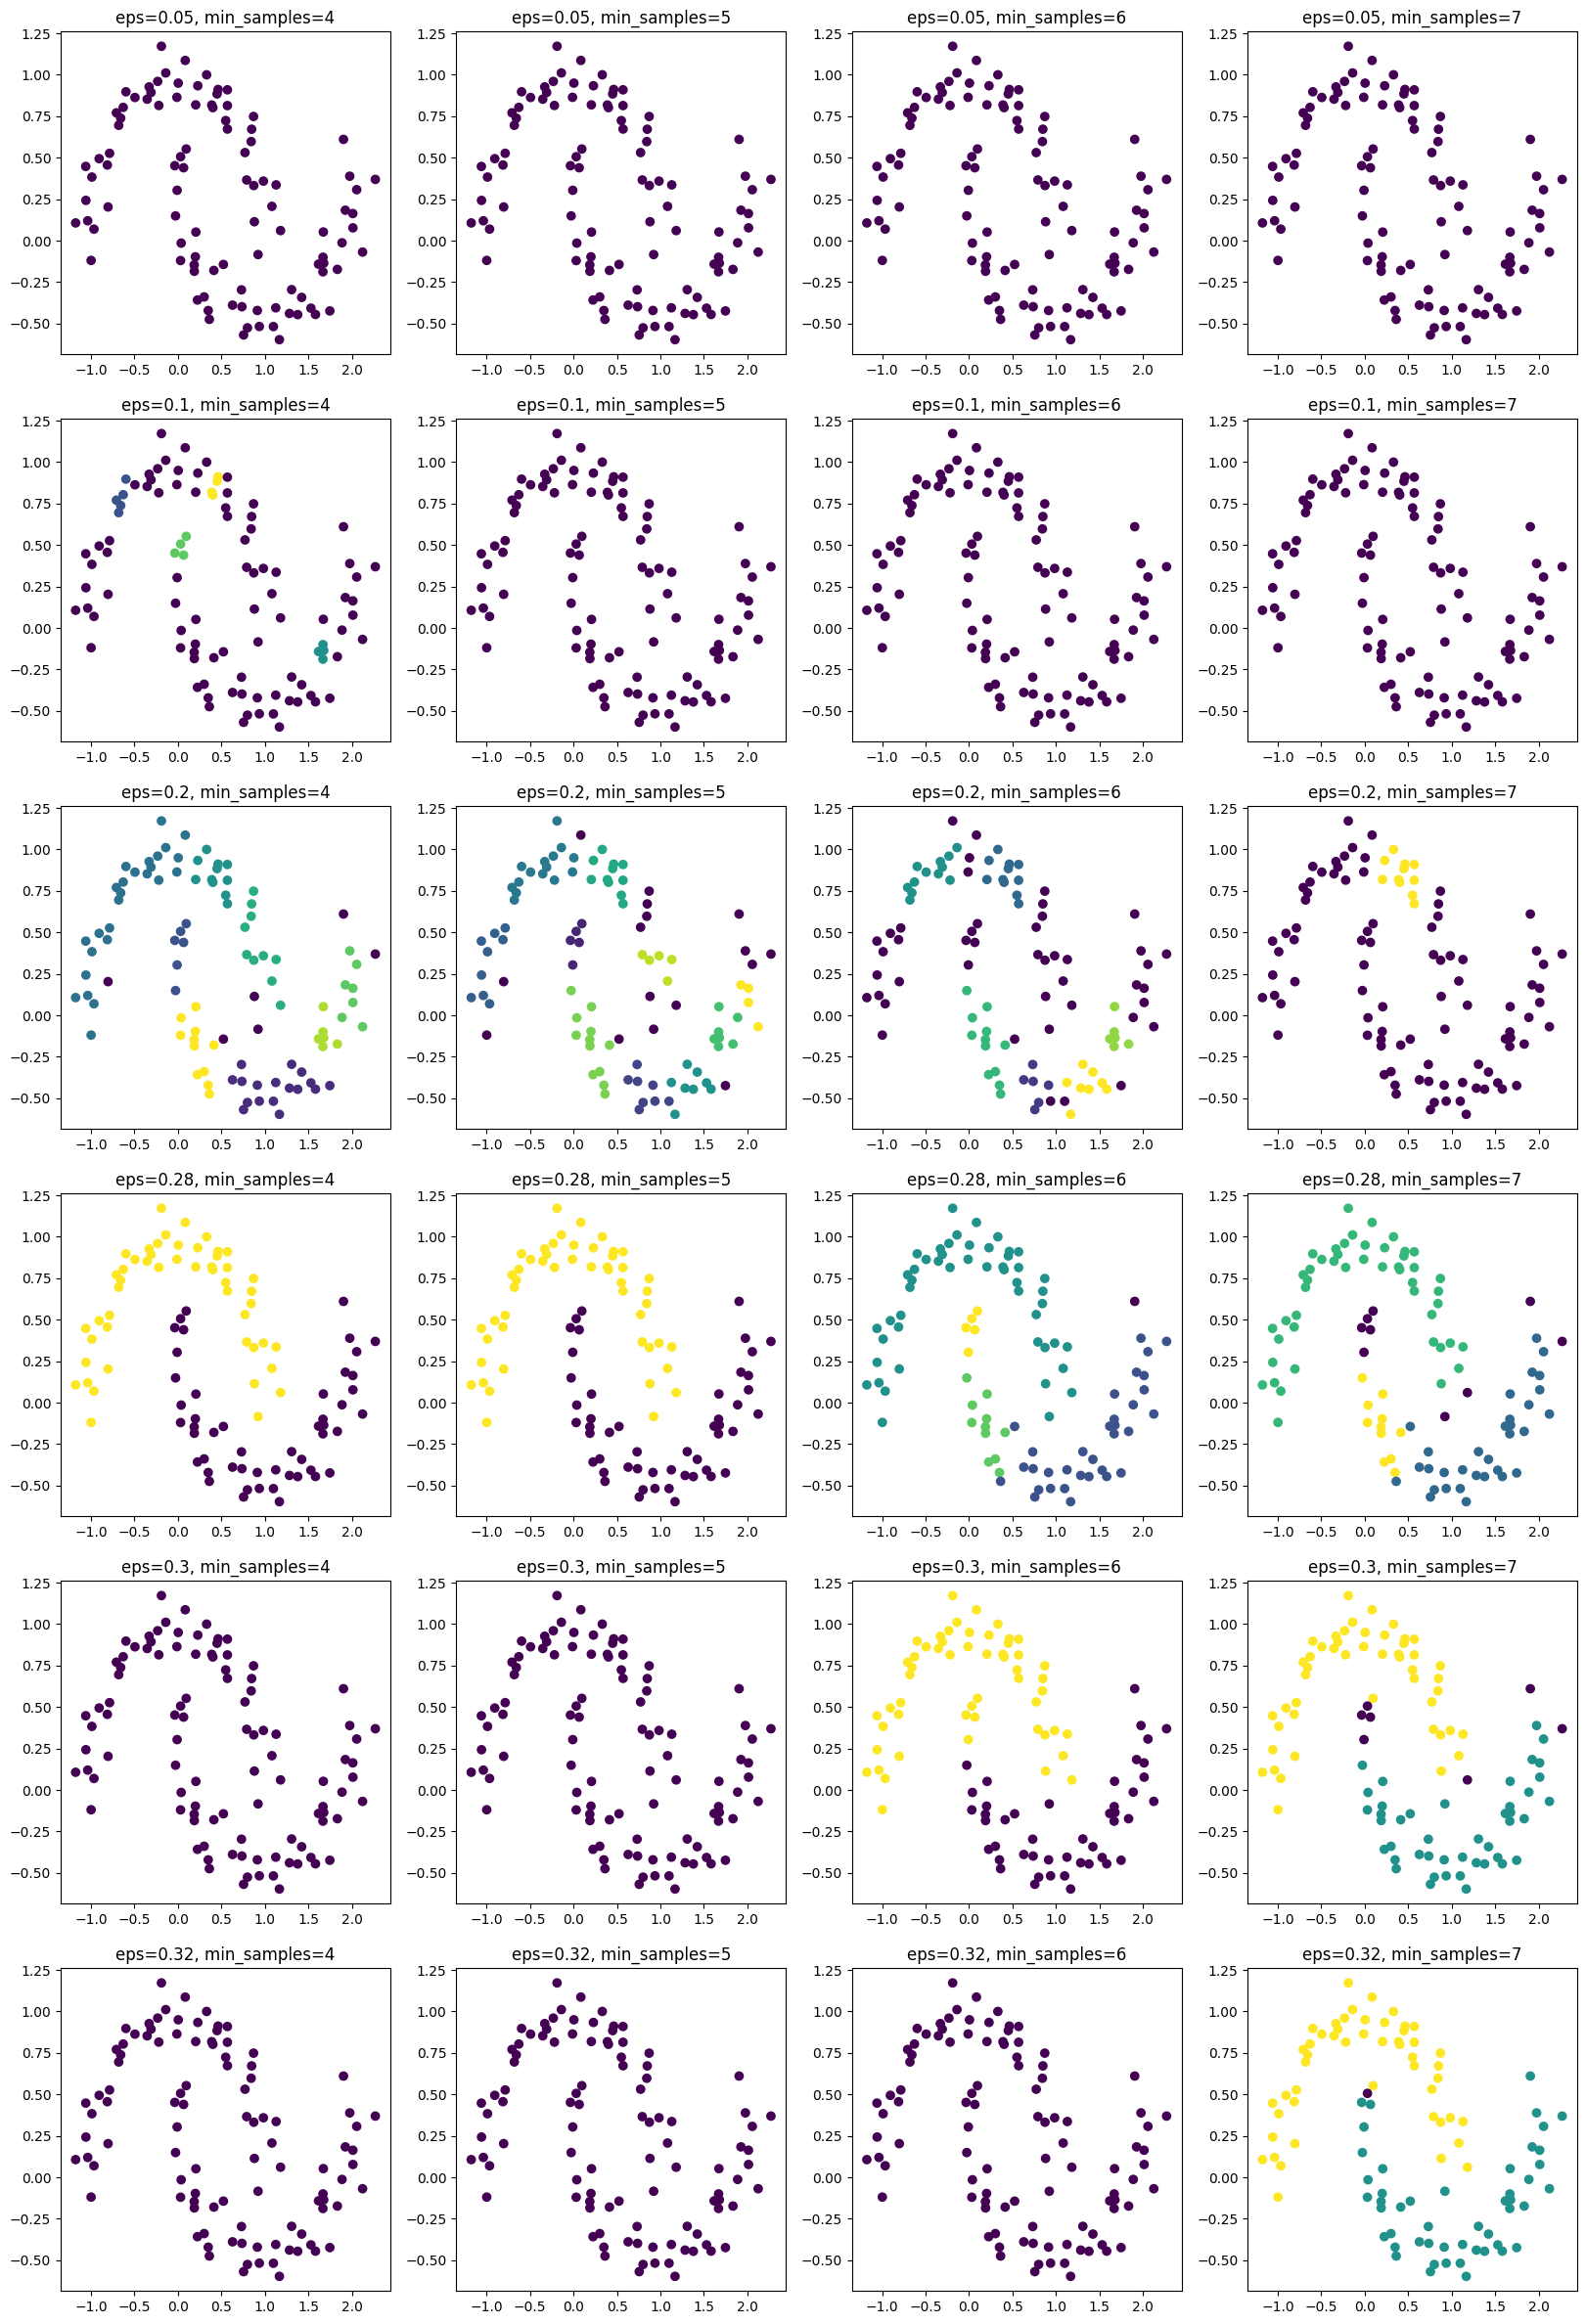

In [122]:
from sklearn.cluster import DBSCAN

plt.figure(figsize=(20, 30))
i = 1
for eps in [0.05, 0.1, 0.2, 0.28, 0.3, 0.32]:
    for min_samples in [4, 5, 6, 7]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X)
        plt.subplot(6, 4, i)
        plt.scatter(X[:,0], X[:,1], c=clusters)
        plt.title(f'eps={eps}, min_samples={min_samples}')
        i += 1
plt.show()

## Quiz

Используйте иерархическую кластеризацию для поиска кластеров.
Задайте в методе 2 кластера. Подберите гиперпараметр linkage из списка ['ward', 'complete', 'average', 'single'], дающий наилучший результат.

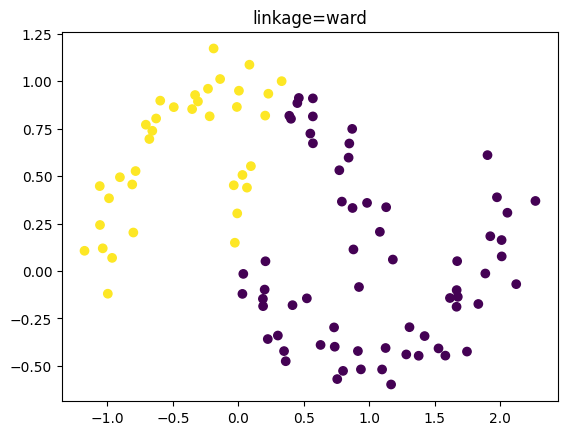

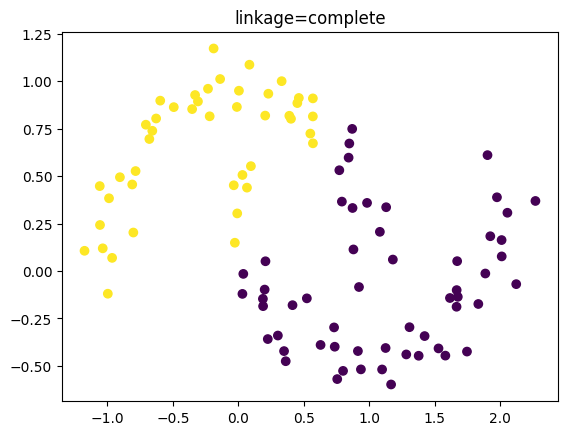

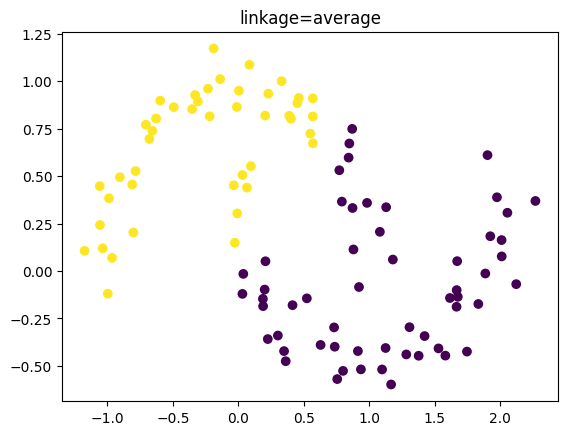

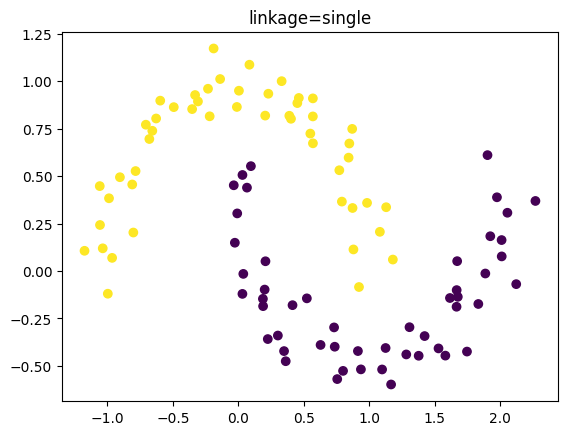

In [125]:
from sklearn.cluster import AgglomerativeClustering

for linkage in ['ward', 'complete', 'average', 'single']:
    agg_clustering = AgglomerativeClustering(n_clusters=2, linkage=linkage)
    clusters = agg_clustering.fit_predict(X)
    plt.scatter(X[:,0], X[:,1], c=clusters)
    plt.title(f'linkage={linkage}')
    plt.show()


## Quiz

Попробуйте найти кластеры при помощи спектральной кластеризации.
Задайте 2 кластера, affinity='nearest_neighbors', random_state=42. Подберите гиперпараметр n_neighbors из диапазона [1,2,...,19], чтобы добиться наилучшего результата.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


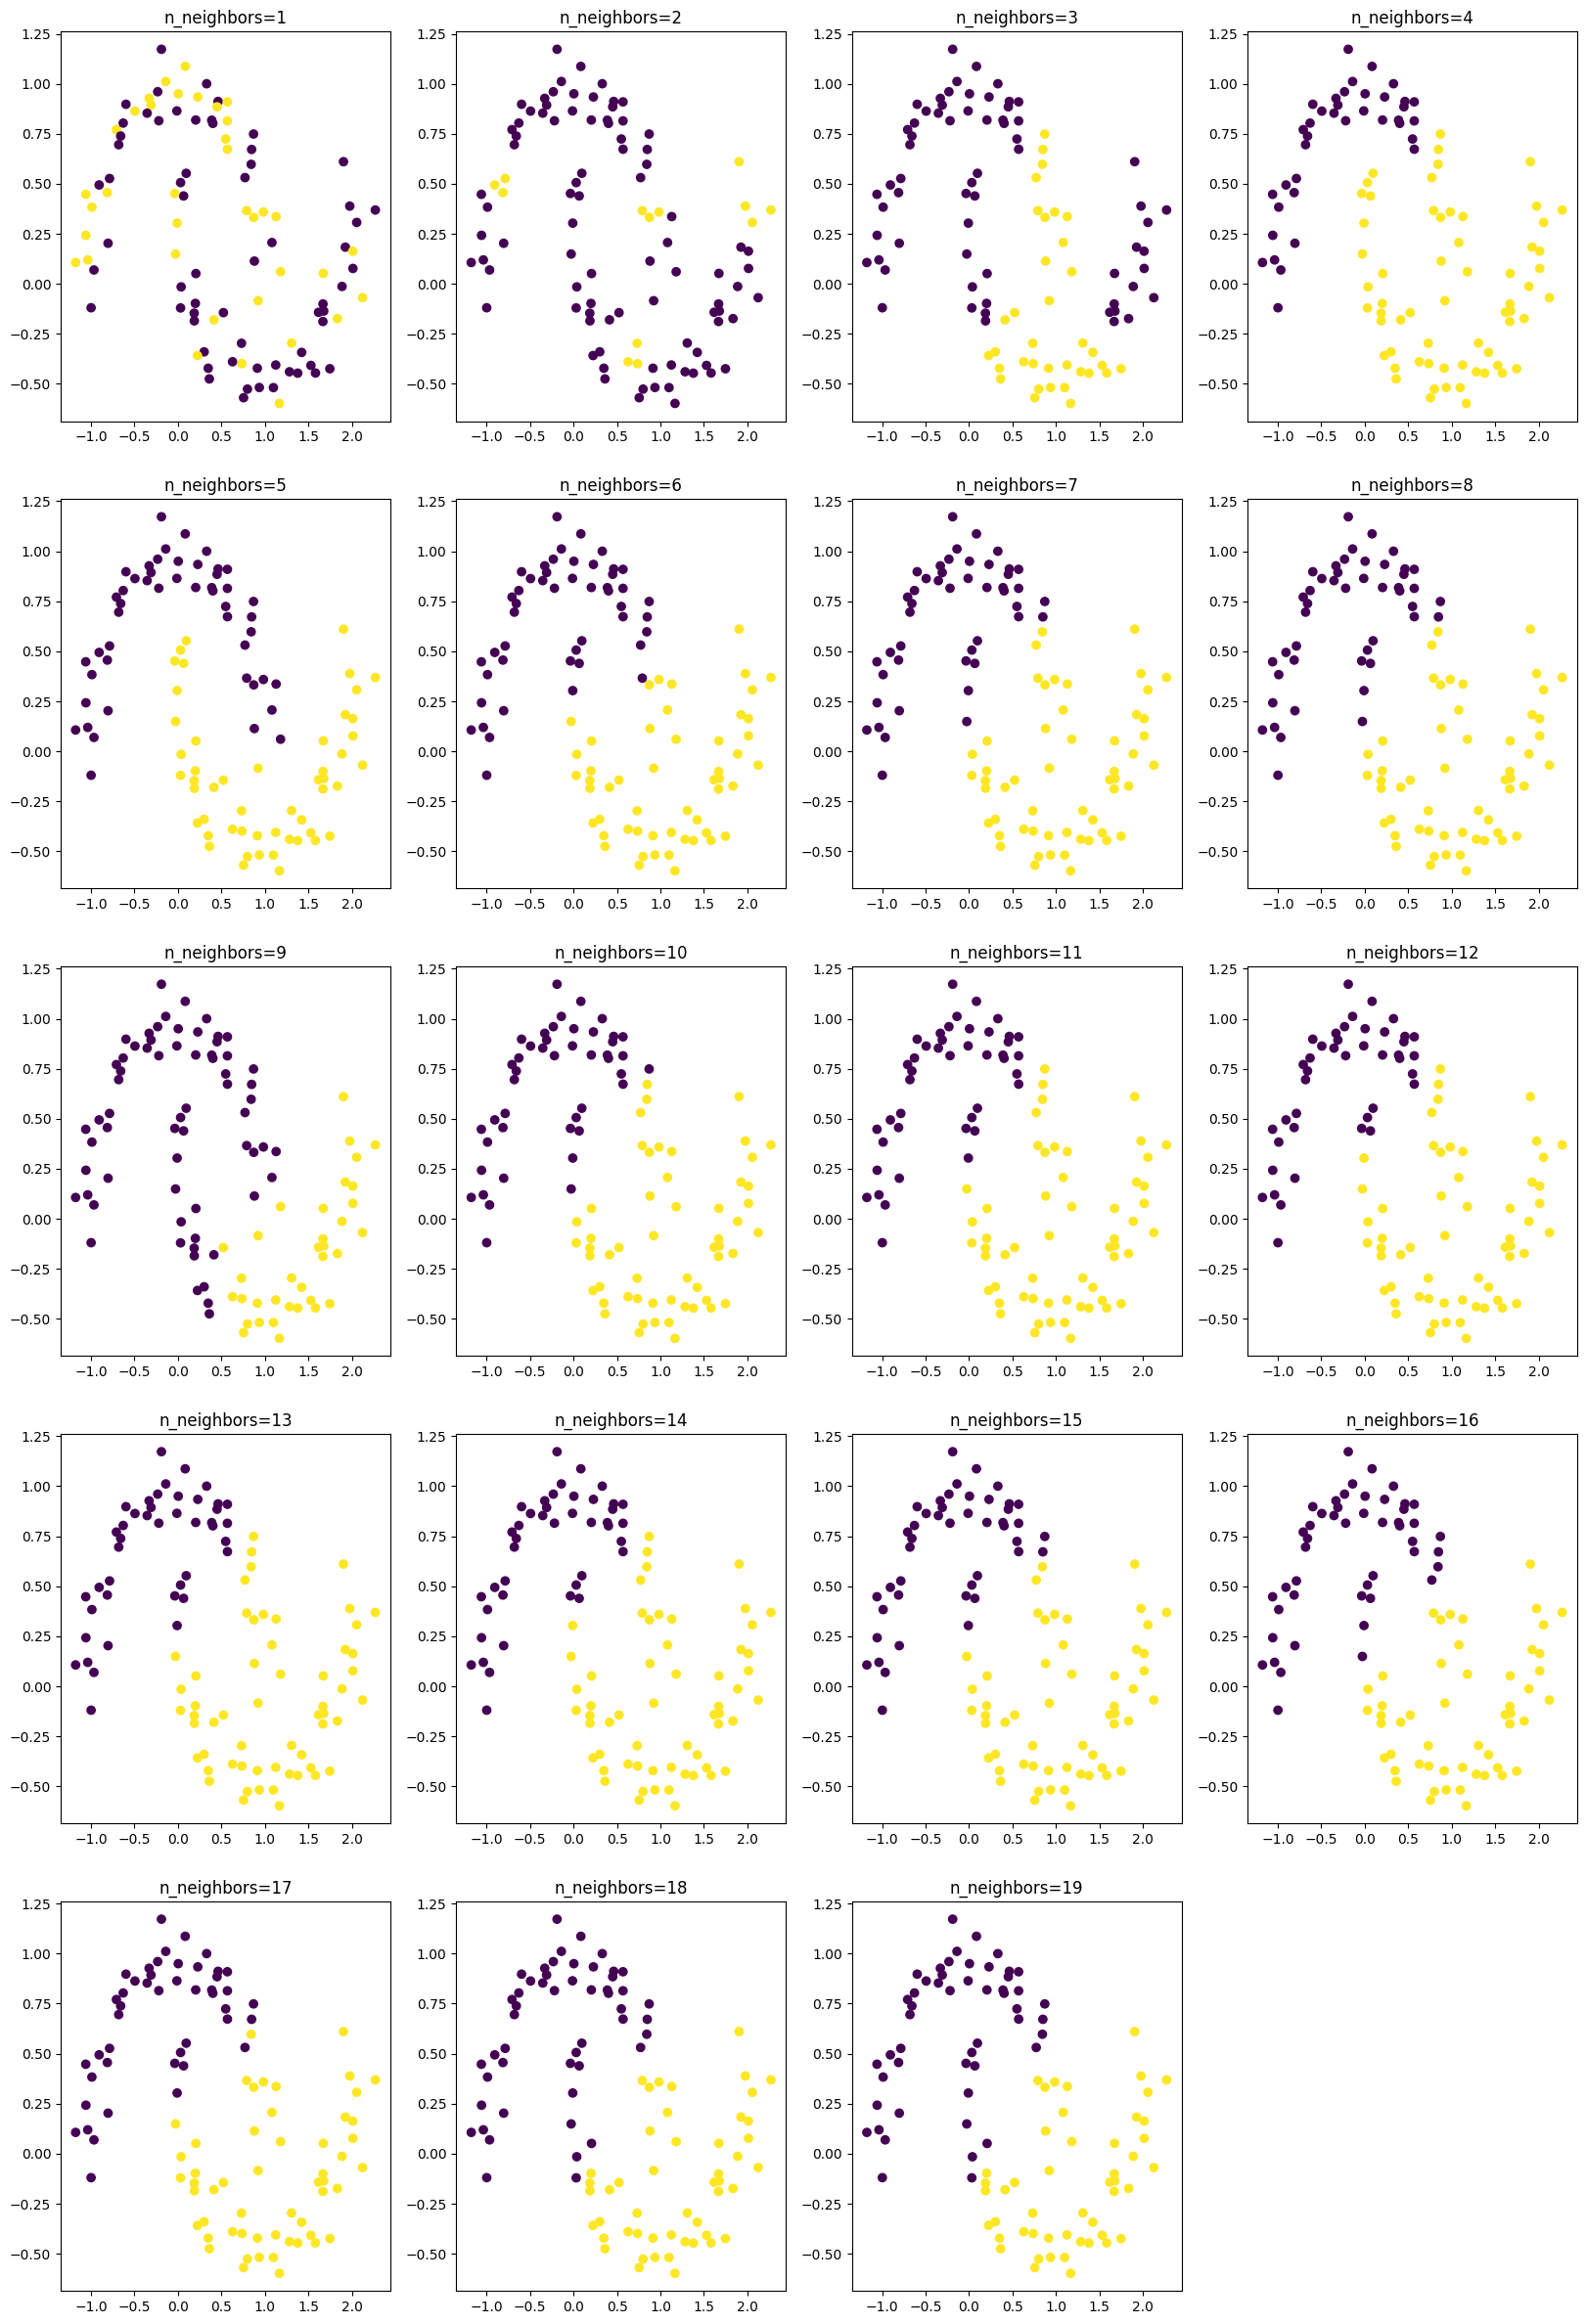

In [129]:
from sklearn.cluster import SpectralClustering

plt.figure(figsize=(20, 30))

for i in range(1, 20):
    clustering = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42, n_neighbors=i)
    clusters = clustering.fit_predict(X)
    plt.subplot(5, 4, i)
    plt.scatter(X[:,0], X[:,1], c=clusters)
    plt.title(f'n_neighbors={i}')

## Quiz

Сделайте выводы: какой метод сработал лучше других? какой метод сработал быстрее? есть ли метод, наилучший и по качеству, и по времени одновременно?

In [130]:
%time
another_kmeans = KMeans(n_clusters=2, random_state=42)
another_kmeans.fit(X)
pred = another_kmeans.predict(X)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 5.96 µs


In [131]:
%time
dbscan = DBSCAN(eps=0.28, min_samples=5)
clusters = dbscan.fit_predict(X)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs


In [132]:
%time
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='single')
clusters = agg_clustering.fit_predict(X)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.44 µs


In [133]:
%time
clustering = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42, n_neighbors=5)
clusters = clustering.fit_predict(X)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.48 µs
